Missing values before handling:
 Date                 0
Temperature (°C)     0
Humidity (%)         0
Wind Speed (km/h)    0
Rainfall (mm)        0
dtype: int64

Monthly Average Temperatures:
 Month
January 2025    15.31
Name: Temperature (°C), dtype: float64


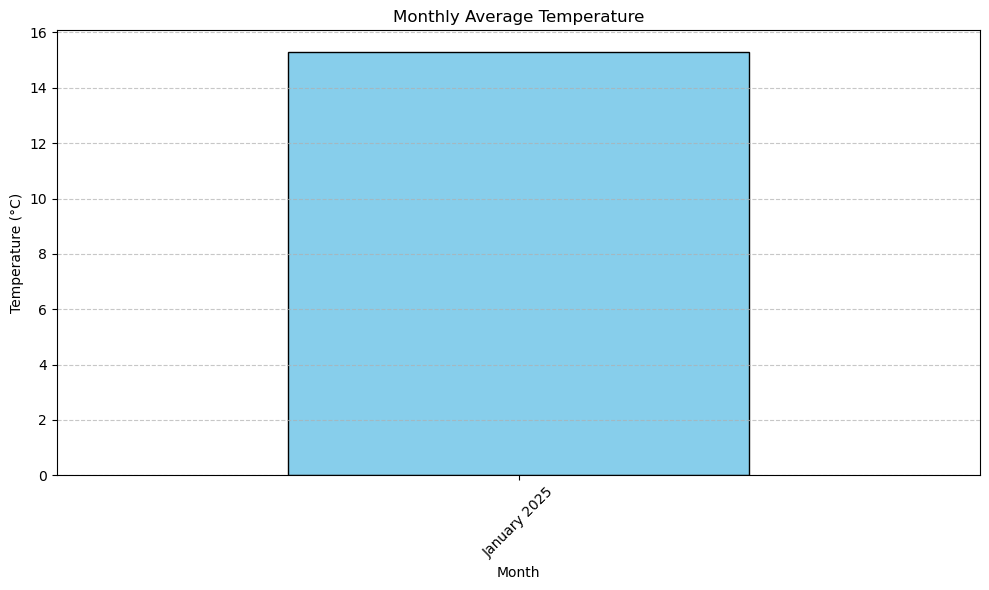

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # Load the dataset
    df = pd.read_csv("C:/Users/DELL/Downloads/weather_data.csv")

    # Display missing values summary
    print("Missing values before handling:\n", df.isnull().sum())

    # 1. Fill missing values in Temperature column (using the exact column name from CSV)
    # Note: If there are no missing values, this won't change anything but keeps the logic safe
    df['Temperature (°C)'] = df['Temperature (°C)'].fillna(df['Temperature (°C)'].mean())

    # 2. Convert 'Date' to datetime objects
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

    # 3. Create a 'Month' column for grouping
    df['Month'] = df['Date'].dt.strftime('%B %Y')

    # 4. Calculate monthly average temperature
    monthly_avg_temp = df.groupby('Month')['Temperature (°C)'].mean()
    print("\nMonthly Average Temperatures:\n", monthly_avg_temp)

    # 5. Visualization
    plt.figure(figsize=(10, 6))
    monthly_avg_temp.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title('Monthly Average Temperature')
    plt.xlabel('Month')
    plt.ylabel('Temperature (°C)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: The file 'weather_data.csv' was not found.")
except KeyError as e:
    print(f"Error: Column name not found in CSV. Please check: {e}")